# PART 2 : Cifar-100

###Imports

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import gc
import collections
tf.keras.mixed_precision.set_global_policy('mixed_float16')

###Data Split

In [ ]:
(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    'cifar100',
    split=['train[:90%]', 'train[90%:]', 'test'],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features['label'].num_classes
CLASS_NAMES = ds_info.features['label'].names
IMG_SIZE = 32

print('Number of classes:', NUM_CLASSES)
print('Class names:', CLASS_NAMES)
print('Train size:', ds_train_raw.cardinality().numpy())
print('Val size  :', ds_val_raw.cardinality().numpy())
print('Test size :', ds_test_raw.cardinality().numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar100/incomplete.Y7UCU9_3.0.2/cifar100-train.tfrecord*...:   0%|       …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar100/incomplete.Y7UCU9_3.0.2/cifar100-test.tfrecord*...:   0%|        …

Dataset cifar100 downloaded and prepared to /root/tensorflow_datasets/cifar100/3.0.2. Subsequent calls will reuse this data.
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sun

###Cifar-100 image samples

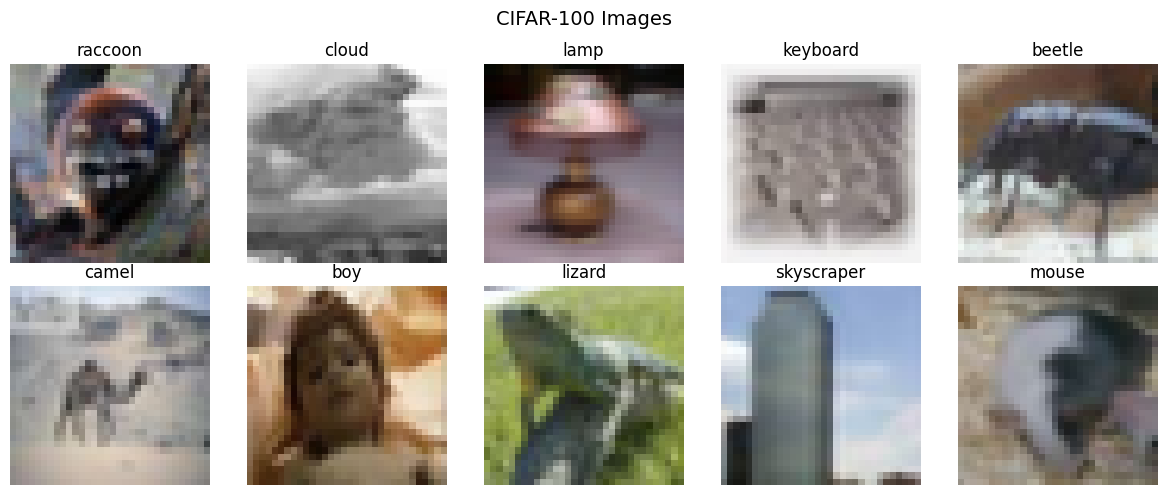

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, (image, label) in zip(axes.flatten(), ds_train_raw.take(10)):
    ax.imshow(image.numpy())
    ax.set_title(CLASS_NAMES[label.numpy()])
    ax.axis('off')
plt.suptitle('CIFAR-100 Images', fontsize=14)
plt.tight_layout()
plt.show()

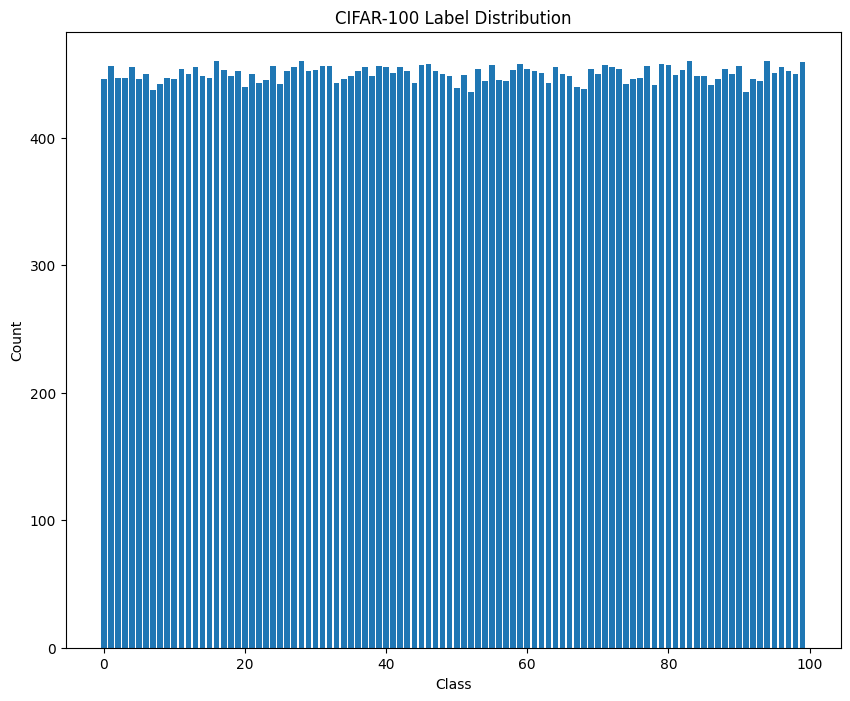

In [ ]:
# label frequency / class distribution
label_counts = collections.Counter()
for _, label in ds_train_raw:
    label_counts[label.numpy()] += 1

plt.figure(figsize=(10, 8))
plt.bar(range(NUM_CLASSES), [label_counts[i] for i in range(NUM_CLASSES)])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('CIFAR-100 Label Distribution')
plt.show()

In [ ]:
# image statistics
sample_images = []
for image, _ in ds_train_raw.take(1000):
    sample_images.append(image.numpy())
sample_images = np.array(sample_images)

print('Image shape:', sample_images[0].shape)
print('Mean pixel value:', sample_images.mean().round(2))
print('Std pixel value:', sample_images.std().round(2))
print('Min pixel value:', sample_images.min())
print('Max pixel value:', sample_images.max())

Image shape: (32, 32, 3)
Mean pixel value: 120.99
Std pixel value: 68.13
Min pixel value: 0
Max pixel value: 255


### Preprocessing

In [ ]:
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

def prepare_dataset(ds, training=False):
    ds = ds.map(normalize, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.shuffle(10000)
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds   = prepare_dataset(ds_val_raw)
test_ds  = prepare_dataset(ds_test_raw)

print('Datasets ready.')

Datasets ready.


###CNN Architecture

In [ ]:
def conv_block(x, filters, dropout_rate):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

def build_cnn(num_classes=100, input_shape=(32, 32, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = conv_block(x, 128,  0.15)
    x = conv_block(x, 256, 0.20)
    x = conv_block(x, 512, 0.25)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inputs, outputs, name='cifar100_cnn')

cnn_model = build_cnn()
cnn_model.summary()

Model: "cifar100_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,179,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,296 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,897,252 (18.68 MB)

 Trainable params: 4,892,644 (18.66 MB)

 Non-trainable params: 4,608 (18.00 KB)

##Training Phase

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],

)

callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        mode='max',
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=2,
        monitor='val_loss',
        min_lr=1e-6,
        verbose=1
    )
]

history_cnn = cnn_model.fit(
    train_ds,
    epochs=32,
    validation_data=val_ds,
    callbacks=callbacks_cnn
)

Epoch 1/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 103ms/step - accuracy: 0.0923 - loss: 3.9813 - val_accuracy: 0.0506 - val_loss: 4.4289 - learning_rate: 0.0010
Epoch 2/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.2095 - loss: 3.1967 - val_accuracy: 0.2024 - val_loss: 3.3452 - learning_rate: 0.0010
Epoch 3/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.3004 - loss: 2.7126 - val_accuracy: 0.1806 - val_loss: 3.7099 - learning_rate: 0.0010
Epoch 4/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.3671 - loss: 2.3941 - val_accuracy: 0.3482 - val_loss: 2.4920 - learning_rate: 0.0010
Epoch 5/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.4138 - loss: 2.1722 - val_accuracy: 0.3676 - val_loss: 2.4615 - learning_rate: 0.0010
Epoch 6/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.4554 - loss: 1.9893 - val_accuracy: 0.3582 - val_loss: 2.5694 - learning_rate: 0.0010
Epoch 7/32
352/352 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.4876 - 

###Plot function

In [ ]:
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



##Test Phase

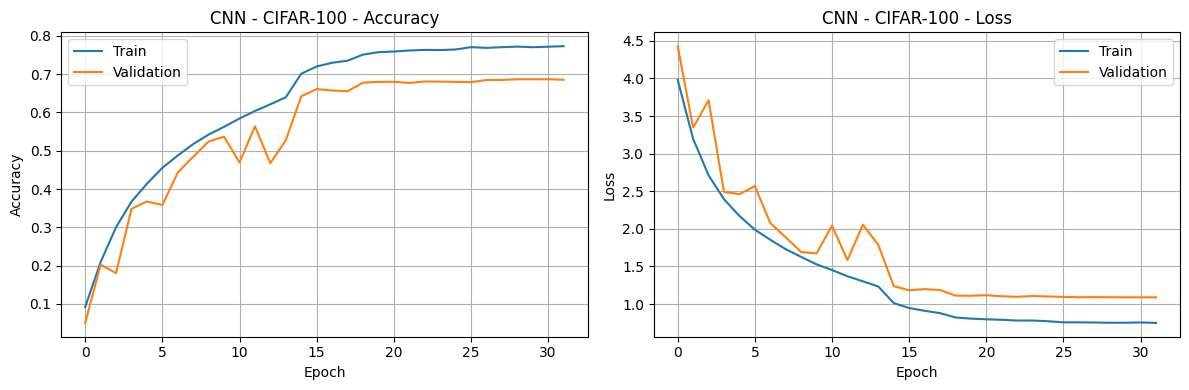

CNN - Test Accuracy: 0.6853  |  Test Loss: 1.1034


In [ ]:
plot_history(history_cnn, 'CNN - CIFAR-100')
loss_cnn, acc_cnn = cnn_model.evaluate(test_ds, verbose=0)
print(f'CNN - Test Accuracy: {acc_cnn:.4f}  |  Test Loss: {loss_cnn:.4f}')

#Transfer Learning + Fine Tuning

###Preprocessing

In [ ]:
PRETRAIN_SIZE = 128
BATCH_SIZE_PT = 64

def normalize_and_resize(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [PRETRAIN_SIZE, PRETRAIN_SIZE])
    return image, label

def prepare_dataset_pretrain(ds, training=False):
    ds = ds.map(normalize_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(2000)
    ds = ds.batch(BATCH_SIZE_PT)
    return ds.prefetch(AUTOTUNE)

train_ds_pt = prepare_dataset_pretrain(ds_train_raw, training=True)
val_ds_pt   = prepare_dataset_pretrain(ds_val_raw)
test_ds_pt  = prepare_dataset_pretrain(ds_test_raw)

print('Pretrain datasets ready.')

Pretrain datasets ready.


###Hyper-Parameters

In [ ]:
def build_transfer_model(base_model, preprocess_fn, num_classes=100):
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(PRETRAIN_SIZE, PRETRAIN_SIZE, 3))
    x = preprocess_fn(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    return tf.keras.Model(inputs, outputs, name=base_model.name + '_classifier')

callbacks_pt = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        mode='max',
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=2,
        monitor='val_loss',
        min_lr=1e-6,
        verbose=1
    )
]

###TL_FT for model : MobileNetV2

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 104ms/step - accuracy: 0.3761 - loss: 2.6410 - val_accuracy: 0.6068 - val_loss: 1.3966 - learning_rate: 0.0010
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5992 - loss: 1.4394 - val_accuracy: 0.6248 - val_loss: 1.3197 - learning_rate: 0.0010
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6351 - loss: 1.2725 - val_accuracy: 0.6422 - val_loss: 1.2733 - learning_rate: 0.0010
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6654 - loss: 1.1512 - val_accuracy: 0.6378 - val_loss: 1.2625 - learning_rate: 0.0010
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6856 - loss: 1.0679 - val_accuracy: 0.6392 - val_loss: 1.2711 - learning_rate: 0.0010
Epoch 6/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6988 - loss: 1.0076
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
704/704 ━━━━━━━━━━━━━

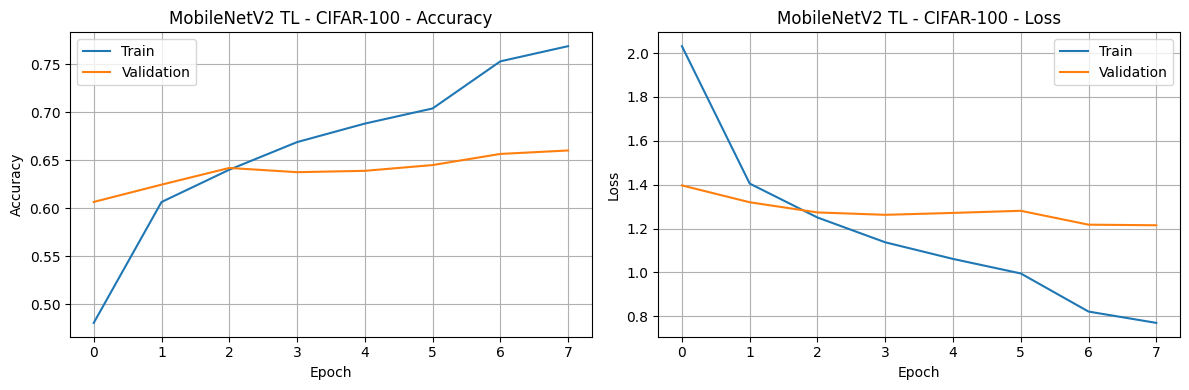

MobileNetV2 TL – Test Accuracy: 0.6598  |  Test Loss: 1.2001
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 292s 231ms/step - accuracy: 0.3956 - loss: 2.6537 - val_accuracy: 0.5476 - val_loss: 1.7441 - learning_rate: 1.0000e-05
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.5782 - loss: 1.5695 - val_accuracy: 0.5776 - val_loss: 1.5490 - learning_rate: 1.0000e-05
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6368 - loss: 1.2903 - val_accuracy: 0.6272 - val_loss: 1.3424 - learning_rate: 1.0000e-05
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.6816 - loss: 1.1103 - val_accuracy: 0.6668 - val_loss: 1.1988 - learning_rate: 1.0000e-05
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.6995 - loss: 1.0222 - val_accuracy: 0.6918 - val_loss: 1.0761 - learning_rate: 1.0000e-05
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.7221 - loss: 0.9301 - val_accuracy: 0.7118 - val_loss: 0.9892 - learning_rate: 1.0000

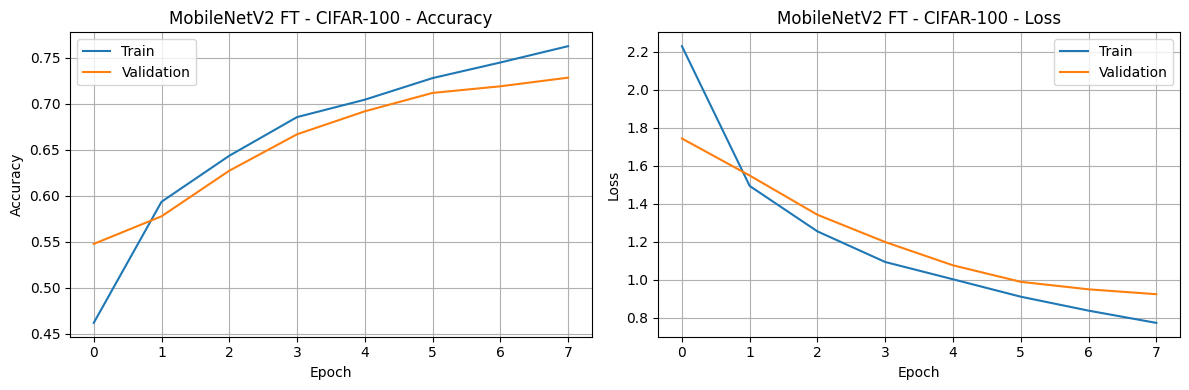

MobileNetV2 FT – Test Accuracy: 0.7286  |  Test Loss: 0.9451


In [ ]:
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(PRETRAIN_SIZE, PRETRAIN_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

mobilenet_model = build_transfer_model(
    mobilenet_base,
    tf.keras.applications.mobilenet_v2.preprocess_input
)

# phase 1 - frozen
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_mobilenet_tl = mobilenet_model.fit(
    train_ds_pt, epochs=8, validation_data=val_ds_pt, callbacks=callbacks_pt
)

plot_history(history_mobilenet_tl, 'MobileNetV2 TL - CIFAR-100')
loss_mb_tl, acc_mb_tl = mobilenet_model.evaluate(test_ds_pt, verbose=0)
print(f'MobileNetV2 TL – Test Accuracy: {acc_mb_tl:.4f}  |  Test Loss: {loss_mb_tl:.4f}')

# phase 2 - fine-tune
mobilenet_base.trainable = True
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_mobilenet_ft = mobilenet_model.fit(
    train_ds_pt, epochs=8, validation_data=val_ds_pt, callbacks=callbacks_pt
)

plot_history(history_mobilenet_ft, 'MobileNetV2 FT - CIFAR-100')
loss_mb, acc_mb = mobilenet_model.evaluate(test_ds_pt, verbose=0)
print(f'MobileNetV2 FT – Test Accuracy: {acc_mb:.4f}  |  Test Loss: {loss_mb:.4f}')

###TL_FT for model : EfficientNetB0

Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 73ms/step - accuracy: 0.4174 - loss: 2.4950 - val_accuracy: 0.6728 - val_loss: 1.1453 - learning_rate: 0.0010
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6377 - loss: 1.2914 - val_accuracy: 0.6870 - val_loss: 1.0733 - learning_rate: 0.0010
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.6708 - loss: 1.1438 - val_accuracy: 0.6990 - val_loss: 1.0317 - learning_rate: 0.0010
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6961 - loss: 1.0437 - val_accuracy: 0.7022 - val_loss: 1.0271 - learning_rate: 0.0010
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7092 - loss: 0.9816 - val_accuracy: 0.7082 - val_loss: 1.0137 - learning_rate: 0.0010
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7277 - loss: 0.9114 - val_accuracy: 0.7132 - val_loss: 1.0276 - learning_rate: 0.0010
Epoch 7/8
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7352 - loss: 0.8

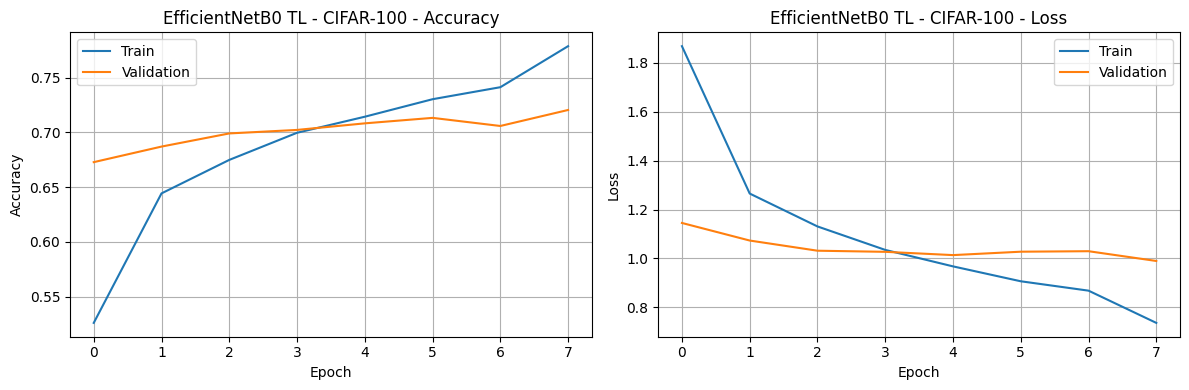

EfficientNetB0 TL – Test Accuracy: 0.7124  |  Test Loss: 1.0120
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 173ms/step - accuracy: 0.4420 - loss: 2.4328 - val_accuracy: 0.6456 - val_loss: 1.3136 - learning_rate: 1.0000e-05
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.5979 - loss: 1.5473 - val_accuracy: 0.6984 - val_loss: 1.0866 - learning_rate: 1.0000e-05
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.6553 - loss: 1.2543 - val_accuracy: 0.7242 - val_loss: 0.9787 - learning_rate: 1.0000e-05
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.6909 - loss: 1.0993 - val_accuracy: 0.7424 - val_loss: 0.9104 - learning_rate: 1.0000e-05
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 100ms/step - accuracy: 0.7138 - loss: 0.9869 - val_accuracy: 0.7498 - val_loss: 0.8608 - learning_rate: 1.0000e-05
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.7301 - loss: 0.9330 - val_accuracy: 0.7606 - val_loss: 0.8252 - learning_rate

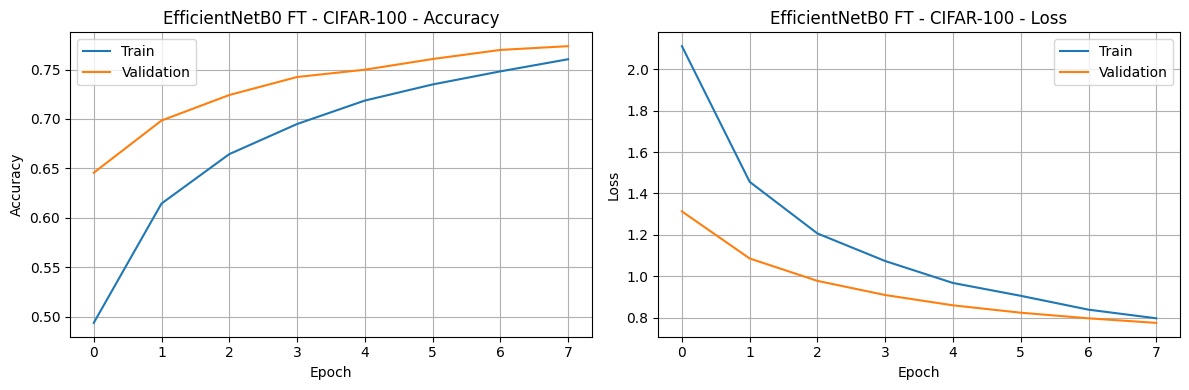

EfficientNetB0 FT – Test Accuracy: 0.7669  |  Test Loss: 0.7979


In [ ]:
tf.keras.backend.clear_session()
gc.collect()

efficientnet_base = tf.keras.applications.EfficientNetB0(
    input_shape=(PRETRAIN_SIZE, PRETRAIN_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

efficientnet_model = build_transfer_model(
    efficientnet_base,
    tf.keras.applications.efficientnet.preprocess_input
)

# phase 1 - frozen
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_efficientnet_tl = efficientnet_model.fit(
    train_ds_pt, epochs=8, validation_data=val_ds_pt, callbacks=callbacks_pt
)

plot_history(history_efficientnet_tl, 'EfficientNetB0 TL - CIFAR-100')
loss_en_tl, acc_en_tl = efficientnet_model.evaluate(test_ds_pt, verbose=0)
print(f'EfficientNetB0 TL – Test Accuracy: {acc_en_tl:.4f}  |  Test Loss: {loss_en_tl:.4f}')

# phase 2 - fine-tune
efficientnet_base.trainable = True
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_efficientnet_ft = efficientnet_model.fit(
    train_ds_pt, epochs=8, validation_data=val_ds_pt, callbacks=callbacks_pt
)

plot_history(history_efficientnet_ft, 'EfficientNetB0 FT - CIFAR-100')
loss_en, acc_en = efficientnet_model.evaluate(test_ds_pt, verbose=0)
print(f'EfficientNetB0 FT – Test Accuracy: {acc_en:.4f}  |  Test Loss: {loss_en:.4f}')

###TL_FT for model : ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 82ms/step - accuracy: 0.4424 - loss: 2.3012 - val_accuracy: 0.6672 - val_loss: 1.1387 - learning_rate: 0.0010
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.6548 - loss: 1.1980 - val_accuracy: 0.6830 - val_loss: 1.0614 - learning_rate: 0.0010
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.6960 - loss: 1.0233 - val_accuracy: 0.6956 - val_loss: 1.0220 - learning_rate: 0.0010
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7283 - loss: 0.9015 - val_accuracy: 0.6994 - val_loss: 1.0095 - learning_rate: 0.0010
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7478 - loss: 0.8238 - val_accuracy: 0.6980 - val_loss: 1.0164 - learning_rate: 0.0010
Epoch 6/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7690 - loss: 0.7495
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
704/704 ━━━━━━━━━━━━━

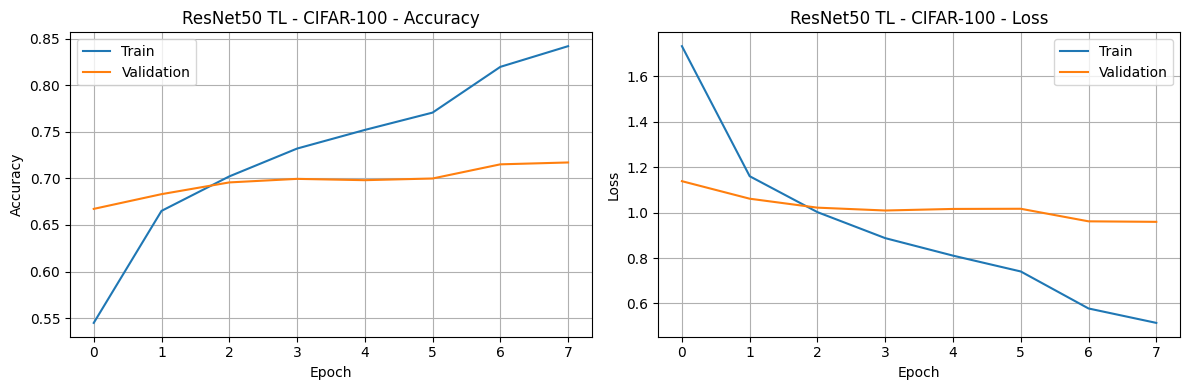

ResNet50 TL – Test Accuracy: 0.7226  |  Test Loss: 0.9759
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 256s 277ms/step - accuracy: 0.6666 - loss: 1.2066 - val_accuracy: 0.7374 - val_loss: 0.9119 - learning_rate: 1.0000e-05
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 234ms/step - accuracy: 0.7966 - loss: 0.6525 - val_accuracy: 0.7566 - val_loss: 0.8347 - learning_rate: 1.0000e-05
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 166s 235ms/step - accuracy: 0.8473 - loss: 0.4861 - val_accuracy: 0.7678 - val_loss: 0.8099 - learning_rate: 1.0000e-05
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 234ms/step - accuracy: 0.8831 - loss: 0.3727 - val_accuracy: 0.7702 - val_loss: 0.7961 - learning_rate: 1.0000e-05
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 234ms/step - accuracy: 0.9115 - loss: 0.2921 - val_accuracy: 0.7760 - val_loss: 0.7882 - learning_rate: 1.0000e-05
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 234ms/step - accuracy: 0.9330 - loss: 0.2318 - val_accuracy: 0.7796 - val_loss: 0.7896 - learning_rate:

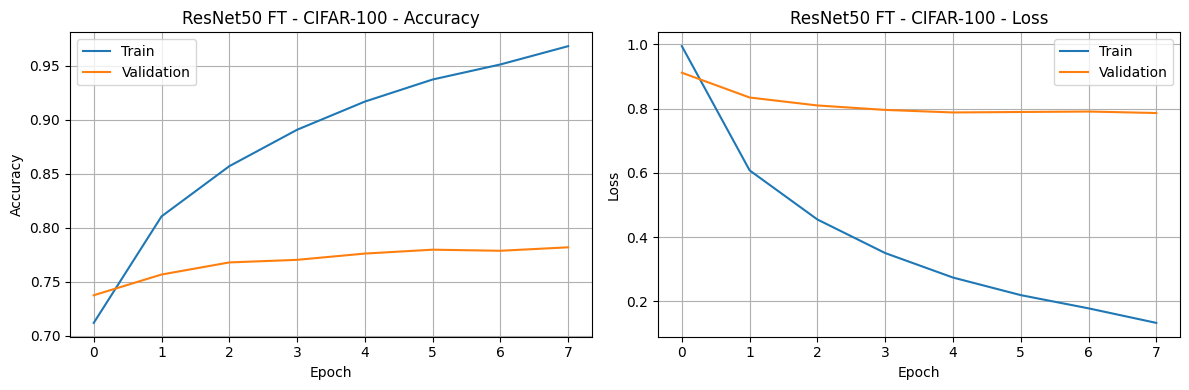

ResNet50 FT – Test Accuracy: 0.7816  |  Test Loss: 0.8068


In [ ]:
tf.keras.backend.clear_session()
gc.collect()

resnet_base = tf.keras.applications.ResNet50(
    input_shape=(PRETRAIN_SIZE, PRETRAIN_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

resnet_model = build_transfer_model(
    resnet_base,
    tf.keras.applications.resnet50.preprocess_input
)

# phase 1 - frozen
resnet_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_resnet_tl = resnet_model.fit(
    train_ds_pt, epochs=8, validation_data=val_ds_pt, callbacks=callbacks_pt
)

plot_history(history_resnet_tl, 'ResNet50 TL - CIFAR-100')
loss_rn_tl, acc_rn_tl = resnet_model.evaluate(test_ds_pt, verbose=0)
print(f'ResNet50 TL – Test Accuracy: {acc_rn_tl:.4f}  |  Test Loss: {loss_rn_tl:.4f}')

# phase 2 - fine-tune
resnet_base.trainable = True
resnet_model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
history_resnet_ft = resnet_model.fit(
    train_ds_pt, epochs=8, validation_data=val_ds_pt, callbacks=callbacks_pt
)

plot_history(history_resnet_ft, 'ResNet50 FT - CIFAR-100')
loss_rn, acc_rn = resnet_model.evaluate(test_ds_pt, verbose=0)
print(f'ResNet50 FT – Test Accuracy: {acc_rn:.4f}  |  Test Loss: {loss_rn:.4f}')